# 🏏 Cricket Match Report Analyzer
### NLP Course Project | Team: Adhi · Khaise · Meera · Indrajith

| Section | Owner | Task |
|---------|-------|------|
| ⚙️ Setup | Everyone | Install libraries |
| 📦 Section 1 | **Adhi** | Data Loading & Preprocessing |
| 🔍 Section 2 | **Khaise** | Named Entity Recognition (NER) |
| 💬 Section 3 | **Meera** | Sentiment Analysis |
| 📂 Section 4 | **Indrajith** | Text Classification + Final Output |

> **Always run cells from top to bottom. Each section builds on the previous one.**

---
## ⚙️ SETUP — Run First (Everyone)

In [7]:
!pip install -q spacy nltk transformers scikit-learn pandas matplotlib seaborn
!python -m spacy download en_core_web_sm -q
import warnings
warnings.filterwarnings('ignore')
print('✅ All libraries installed and ready!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 94.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed and ready!


---
## 📦 SECTION 1 — Data Loading & Preprocessing
### 👤 Owner: Adhi

**Goal:** Upload the 3 CSV files, parse each row into structured fields, clean the commentary text, and prepare the DataFrame for all other sections.

### Step 1.1 — Upload the CSV Files

In [8]:
from google.colab import files
import pandas as pd
import re
import os

print('📁 Upload train.csv, test.csv, and validation.csv:')
uploaded = files.upload()

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
val   = pd.read_csv('validation.csv')

df_raw = pd.concat([train, test, val], ignore_index=True)
print(f'\n✅ Total rows loaded: {len(df_raw)}')
print(df_raw.head(2))

📁 Upload train.csv, test.csv, and validation.csv:


Saving test.csv to test.csv
Saving train.csv to train.csv
Saving validation.csv to validation.csv

✅ Total rows loaded: 90401
                                                rows
0  <start_of_table> play type description is no r...
1  <start_of_table> play type description is run ...


### Step 1.2 — Parse Each Row Into Structured Fields

In [9]:
def parse_row(text):
    """
    Each row format:
    <start_of_table> ...fields... <end_of_table> commentary <text>
    Extracts: play_type, batting_team, bowling_team, bowler, batsman, runs, commentary
    """
    text = str(text)

    def get(field):
        m = re.search(field + r' is ([^<]+?)(?= \w+ \w+ is |<end_of_table>)', text)
        return m.group(1).strip() if m else ''

    commentary = ''
    if '<end_of_table>' in text:
        after = text.split('<end_of_table>')[1]
        commentary = after.replace('commentary', '', 1).strip()

    return {
        'play_type'   : get('play type description'),
        'batting_team': get('batting team'),
        'bowling_team': get('bowling team'),
        'bowler'      : get('bowler name'),
        'batsman'     : get('batsman name'),
        'runs'        : get('total runs on delivery'),
        'dismissal'   : get('dismissal is'),
        'commentary'  : commentary
    }

print('⏳ Parsing all rows... (may take 1-2 mins for 90k rows)')
parsed = df_raw['rows'].apply(parse_row)
df = pd.DataFrame(list(parsed))
print(f'✅ Parsed! Shape: {df.shape}')
print('\n📋 Columns:', list(df.columns))
display(df.head(3))

⏳ Parsing all rows... (may take 1-2 mins for 90k rows)
✅ Parsed! Shape: (90401, 8)

📋 Columns: ['play_type', 'batting_team', 'bowling_team', 'bowler', 'batsman', 'runs', 'dismissal', 'commentary']


,play_type,batting_team,bowling_team,bowler,batsman,runs,dismissal,commentary
0,no run,India,England total runs,James Anderson,Shikhar Dhawan,0,,short of a length and some shape into off stum...
1,run,India,England total runs,James Anderson,Shikhar Dhawan,2,,"length on leg stump, stays back and clips it t..."
2,no run,India,England total runs,James Anderson,Shikhar Dhawan,0,,"full and just outside off, no swing back this ..."


### Step 1.3 — Clean the Commentary Text

In [10]:
def clean_text(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r"[^A-Za-z0-9.,!?'\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_commentary'] = df['commentary'].apply(clean_text)
df = df[df['clean_commentary'].str.len() > 10].reset_index(drop=True)

print(f'✅ Cleaned! Rows kept: {len(df)}')
print('\n📝 Sample:')
print(df['clean_commentary'].iloc[0])

✅ Cleaned! Rows kept: 89338

📝 Sample:
short of a length and some shape into off stump. Allows it come on and dabs with soft hands in front of point


### Step 1.4 — Explore the Data

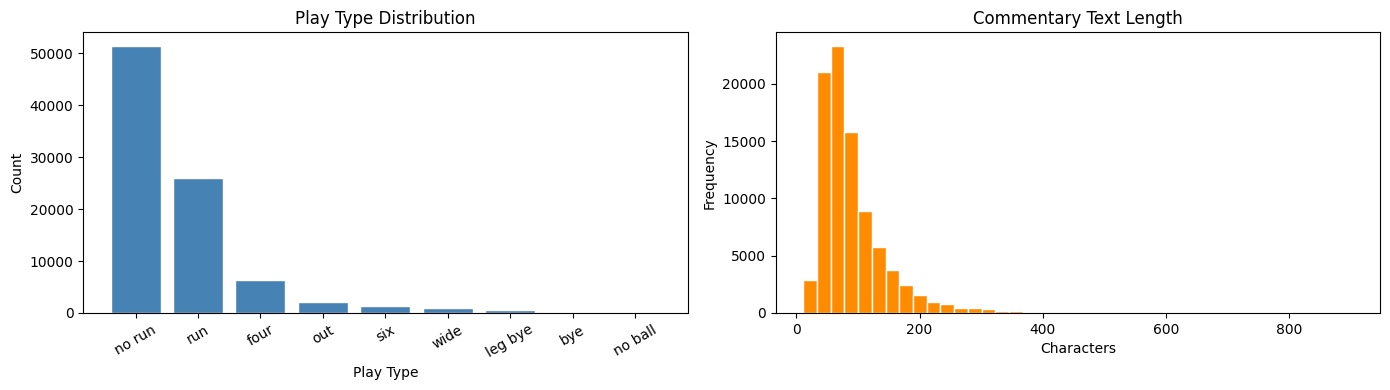


📊 Summary:
  Total rows     : 89338
  Unique batsmen : 393
  Unique bowlers : 268
  Play types     : ['no run', 'run', 'leg bye', 'four', 'out', 'bye', 'wide', 'six', 'no ball']

✅ Section 1 Complete — Adhi done!


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

play_counts = df['play_type'].value_counts()
axes[0].bar(play_counts.index, play_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Play Type Distribution')
axes[0].set_xlabel('Play Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

df['text_len'] = df['clean_commentary'].apply(len)
axes[1].hist(df['text_len'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Commentary Text Length')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'\n📊 Summary:')
print(f'  Total rows     : {len(df)}')
print(f'  Unique batsmen : {df["batsman"].nunique()}')
print(f'  Unique bowlers : {df["bowler"].nunique()}')
print(f'  Play types     : {list(df["play_type"].unique())}')
print('\n✅ Section 1 Complete — Adhi done!')

---
## 🔍 SECTION 2 — Named Entity Recognition (NER)
### 👤 Owner: Khaise

**Goal:** Extract player names, team names, and venues from commentary using spaCy + structured fields.

### Step 2.1 — Load spaCy & Define Extractor

In [12]:
import spacy
from collections import Counter

nlp = spacy.load('en_core_web_sm')

CRICKET_VENUES = [
    'wankhede', 'eden gardens', 'lords', "lord's", 'oval', 'gabba',
    'mcg', 'scg', 'headingley', 'old trafford', 'chepauk', 'chinnaswamy',
    'feroz shah kotla', 'narendra modi stadium'
]

def extract_entities(row):
    # From structured fields (most accurate)
    players = [p for p in [row['batsman'], row['bowler']] if p]
    teams   = [t for t in [row['batting_team'], row['bowling_team']] if t]

    # Extra players from commentary text via spaCy
    doc = nlp(row['clean_commentary'][:300])
    for ent in doc.ents:
        if ent.label_ == 'PERSON':
            players.append(ent.text.strip())

    # Venue detection
    venues = [v.title() for v in CRICKET_VENUES if v in row['clean_commentary'].lower()]

    return {
        'ner_players': list(set(players)),
        'ner_teams'  : list(set(teams)),
        'ner_venues' : list(set(venues))
    }

print('✅ NER extractor ready!')

✅ NER extractor ready!


### Step 2.2 — Run NER (on 500 rows for speed)

In [13]:
sample_df = df.head(500).copy()

print('⏳ Running NER...')
ner_results = sample_df.apply(extract_entities, axis=1)
sample_df['ner_players'] = ner_results.apply(lambda x: x['ner_players'])
sample_df['ner_teams']   = ner_results.apply(lambda x: x['ner_teams'])
sample_df['ner_venues']  = ner_results.apply(lambda x: x['ner_venues'])

print('✅ NER complete!')
for i in range(3):
    print(f'\n--- Row {i+1} ---')
    print(f'Commentary : {sample_df["clean_commentary"].iloc[i][:100]}')
    print(f'Players    : {sample_df["ner_players"].iloc[i]}')
    print(f'Teams      : {sample_df["ner_teams"].iloc[i]}')

⏳ Running NER...
✅ NER complete!

--- Row 1 ---
Commentary : short of a length and some shape into off stump. Allows it come on and dabs with soft hands in front
Players    : ['James Anderson', 'Shikhar Dhawan']
Teams      : ['India', 'England total runs']

--- Row 2 ---
Commentary : length on leg stump, stays back and clips it through square leg off the back foot
Players    : ['James Anderson', 'Shikhar Dhawan']
Teams      : ['India', 'England total runs']

--- Row 3 ---
Commentary : full and just outside off, no swing back this time, just angle. Watches it carefully and taps to poi
Players    : ['James Anderson', 'Shikhar Dhawan']
Teams      : ['India', 'England total runs']


### Step 2.3 — Most Mentioned Players & Teams

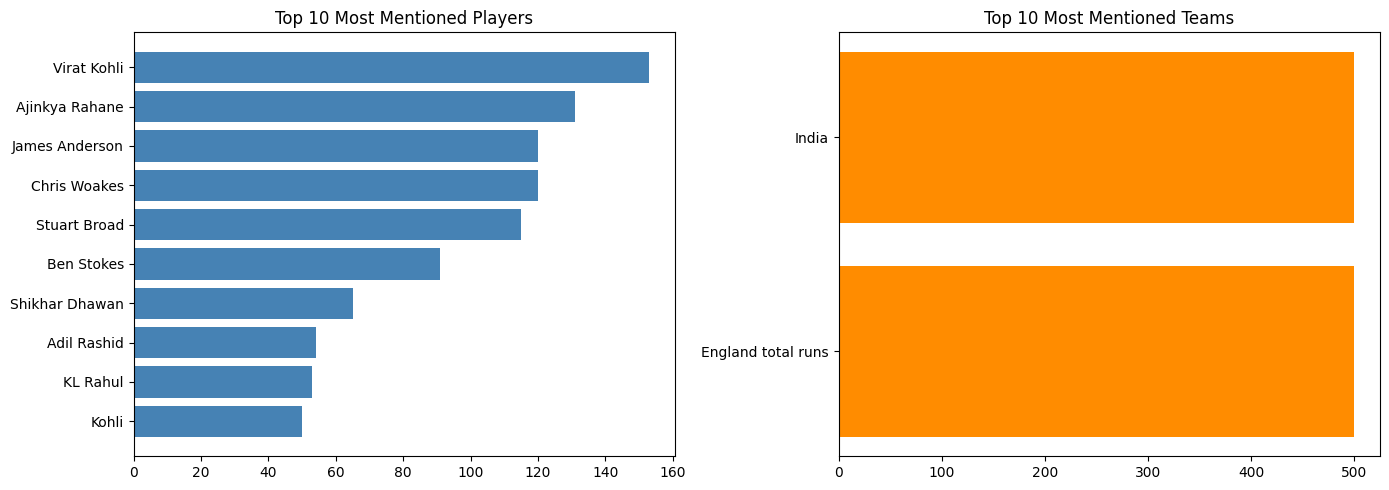


✅ Section 2 Complete — Khaise done!


In [14]:
all_players = [p for lst in sample_df['ner_players'] for p in lst]
all_teams   = [t for lst in sample_df['ner_teams']   for t in lst]

player_counts = Counter(all_players).most_common(10)
team_counts   = Counter(all_teams).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if player_counts:
    names, counts = zip(*player_counts)
    axes[0].barh(names, counts, color='steelblue')
    axes[0].set_title('Top 10 Most Mentioned Players')
    axes[0].invert_yaxis()

if team_counts:
    tnames, tcounts = zip(*team_counts)
    axes[1].barh(tnames, tcounts, color='darkorange')
    axes[1].set_title('Top 10 Most Mentioned Teams')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print('\n✅ Section 2 Complete — Khaise done!')

---
## 💬 SECTION 3 — Sentiment Analysis
### 👤 Owner: Meera

**Goal:** Detect the tone of each commentary — positive (boundary, praise) or negative (dot ball, dismissal pressure).

### Step 3.1 — Load Sentiment Model

In [15]:
from transformers import pipeline

print('⏳ Loading model (first time ~1 min)...')
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512
)
print('✅ Sentiment model loaded!')

⏳ Loading model (first time ~1 min)...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✅ Sentiment model loaded!


### Step 3.2 — Run Sentiment Analysis

In [16]:
def get_sentiment(text):
    try:
        result = sentiment_pipeline(text[:512])[0]
        return result['label'], round(result['score'], 3)
    except:
        return 'NEUTRAL', 0.5

print('⏳ Running sentiment on 500 rows...')
sentiments = sample_df['clean_commentary'].apply(get_sentiment)
sample_df['sentiment_label'] = sentiments.apply(lambda x: x[0])
sample_df['sentiment_score'] = sentiments.apply(lambda x: x[1])

print('✅ Done!')
print('\n📊 Distribution:')
print(sample_df['sentiment_label'].value_counts())
display(sample_df[['clean_commentary','sentiment_label','sentiment_score']].head(5))

⏳ Running sentiment on 500 rows...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Done!

📊 Distribution:
sentiment_label
NEGATIVE    313
POSITIVE    187
Name: count, dtype: int64


,clean_commentary,sentiment_label,sentiment_score
0,short of a length and some shape into off stum...,POSITIVE,0.912
1,"length on leg stump, stays back and clips it t...",NEGATIVE,0.781
2,"full and just outside off, no swing back this ...",POSITIVE,0.901
3,good length inswinger starts on leg and curves...,POSITIVE,0.964
4,short of a length and slanting across the corr...,NEGATIVE,0.999


### Step 3.3 — Visualize Sentiment

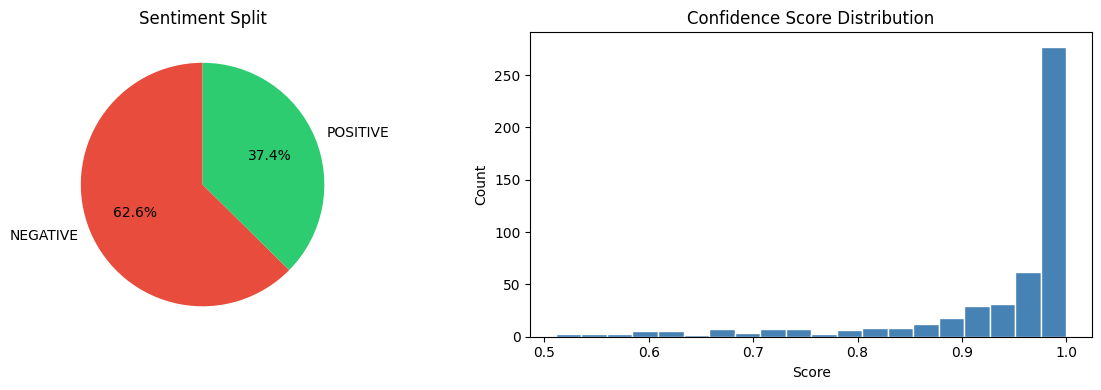


✅ Section 3 Complete — Meera done!


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = sample_df['sentiment_label'].value_counts()
colors = ['#2ecc71' if l == 'POSITIVE' else '#e74c3c' for l in counts.index]
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Sentiment Split')

axes[1].hist(sample_df['sentiment_score'], bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Confidence Score Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print('\n✅ Section 3 Complete — Meera done!')

---
## 📂 SECTION 4 — Text Classification + Final Output
### 👤 Owner: Indrajith

**Goal:** Train an ML classifier to predict play type (no run / four / six / out / wide etc.) from commentary text, then combine all outputs into a final demo.

### Step 4.1 — Prepare Labels

In [18]:
from sklearn.preprocessing import LabelEncoder

clf_df = df[df['play_type'].notna() & (df['play_type'] != '')].copy()
clf_df = clf_df[clf_df['clean_commentary'].str.len() > 10].copy()

le = LabelEncoder()
clf_df['label'] = le.fit_transform(clf_df['play_type'])

print(f'✅ {len(clf_df)} rows ready for classification')
print('\n📋 Classes:')
for i, cls in enumerate(le.classes_):
    count = (clf_df['play_type'] == cls).sum()
    print(f'  {i} → {cls:12s} ({count} rows)')

✅ 89338 rows ready for classification

📋 Classes:
  0 → bye          (180 rows)
  1 → four         (6431 rows)
  2 → leg bye      (625 rows)
  3 → no ball      (121 rows)
  4 → no run       (51489 rows)
  5 → out          (2140 rows)
  6 → run          (25969 rows)
  7 → six          (1388 rows)
  8 → wide         (995 rows)


### Step 4.2 — Train TF-IDF + Logistic Regression

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X = clf_df['clean_commentary']
y = clf_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf    = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
ml_model = LogisticRegression(max_iter=300, C=1.0)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

ml_model.fit(X_train_vec, y_train)
y_pred = ml_model.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)

print(f'✅ Model trained! Accuracy: {acc:.2%}')
print('\n📊 Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

✅ Model trained! Accuracy: 90.06%

📊 Classification Report:
              precision    recall  f1-score   support

         bye       1.00      0.14      0.24        36
        four       0.87      0.80      0.83      1286
     leg bye       0.96      0.37      0.53       125
     no ball       0.00      0.00      0.00        24
      no run       0.91      0.97      0.94     10298
         out       0.87      0.78      0.82       428
         run       0.89      0.85      0.87      5194
         six       0.90      0.74      0.81       278
        wide       0.86      0.61      0.72       199

    accuracy                           0.90     17868
   macro avg       0.81      0.58      0.64     17868
weighted avg       0.90      0.90      0.90     17868



### Step 4.3 — Final Combined Table

In [20]:
final_df = sample_df[['clean_commentary','ner_players','ner_teams','sentiment_label','sentiment_score','play_type']].copy()
final_df.columns = ['Commentary','Players','Teams','Sentiment','Confidence','Play Type']

print('🏏 Final Combined Results:')
display(final_df.head(10))

final_df.to_csv('cricket_nlp_results.csv', index=False)
print('\n✅ Saved to cricket_nlp_results.csv')

🏏 Final Combined Results:


,Commentary,Players,Teams,Sentiment,Confidence,Play Type
0,short of a length and some shape into off stum...,"[James Anderson, Shikhar Dhawan]","[India, England total runs]",POSITIVE,0.912,no run
1,"length on leg stump, stays back and clips it t...","[James Anderson, Shikhar Dhawan]","[India, England total runs]",NEGATIVE,0.781,run
2,"full and just outside off, no swing back this ...","[James Anderson, Shikhar Dhawan]","[India, England total runs]",POSITIVE,0.901,no run
3,good length inswinger starts on leg and curves...,"[James Anderson, Bairstow, Shikhar Dhawan]","[India, England total runs]",POSITIVE,0.964,no run
4,short of a length and slanting across the corr...,"[James Anderson, Shikhar Dhawan]","[India, England total runs]",NEGATIVE,0.999,no run
5,"short of a length and angled across off, left ...","[James Anderson, Shikhar Dhawan]","[India, England total runs]",NEGATIVE,0.993,no run
6,some wobble for Broad outside off. Good length...,"[KL Rahul, Broad, Stuart Broad]","[India, England total runs]",NEGATIVE,0.864,no run
7,short of a length and just outside off. Left a...,"[KL Rahul, Stuart Broad]","[India, England total runs]",NEGATIVE,0.999,no run
8,"short of a length on off stump, defended off t...","[KL Rahul, Stuart Broad]","[India, England total runs]",NEGATIVE,0.899,no run
9,"beats him. That's a great line, he's hit it co...","[KL Rahul, Stuart Broad]","[India, England total runs]",POSITIVE,0.999,no run



✅ Saved to cricket_nlp_results.csv


### Step 4.4 — 🎯 DEMO: Analyze Any Cricket Commentary

In [21]:
import re
import spacy
nlp = spacy.load('en_core_web_sm')

In [22]:
import re
import spacy

nlp = spacy.load('en_core_web_sm')

CRICKET_VENUES = [
    'wankhede', 'eden gardens', 'lords', "lord's", 'oval', 'gabba',
    'mcg', 'scg', 'headingley', 'old trafford', 'chepauk', 'chinnaswamy',
    'feroz shah kotla', 'narendra modi stadium'
]

def get_sentiment(text):
    try:
        result = sentiment_pipeline(text[:512])[0]
        return result['label'], round(result['score'], 3)
    except:
        return 'NEUTRAL', 0.5

def analyze_commentary(text):
    print('='*60)
    print('🏏 CRICKET COMMENTARY ANALYZER')
    print('='*60)

    cleaned = re.sub(r'\s+', ' ', text.strip())
    print(f'\n📝 Input: {cleaned[:200]}')

    # NER
    doc = nlp(cleaned)
    players = list(set([e.text for e in doc.ents if e.label_ == 'PERSON']))
    venues  = [v.title() for v in CRICKET_VENUES if v in cleaned.lower()]
    print(f'\n🔍 Named Entities:')
    print(f'  Players : {players if players else "None detected"}')
    print(f'  Venues  : {venues  if venues  else "None detected"}')

    # Sentiment
    label, score = get_sentiment(cleaned)
    emoji = '😊' if label == 'POSITIVE' else '😞'
    print(f'\n💬 Sentiment : {emoji} {label} (confidence: {score})')

    # Classification
    vec  = tfidf.transform([cleaned])
    pred = ml_model.predict(vec)[0]
    prob = ml_model.predict_proba(vec).max()
    play = le.inverse_transform([pred])[0]
    print(f'\n📂 Play Type : {play} (confidence: {prob:.2%})')
    print('='*60)


analyze_commentary(
    'Kohli drives beautifully through the covers for a magnificent four! '
    'The crowd erupts at Wankhede as India take control of the chase.'
)

🏏 CRICKET COMMENTARY ANALYZER

📝 Input: Kohli drives beautifully through the covers for a magnificent four! The crowd erupts at Wankhede as India take control of the chase.

🔍 Named Entities:
  Players : None detected
  Venues  : ['Wankhede']

💬 Sentiment : 😊 POSITIVE (confidence: 1.0)

📂 Play Type : four (confidence: 84.80%)


In [26]:
# ---- TRY YOUR OWN ----
my_text = """
Down the leg side, way outside off stump, the umpire raises his hand immediately. Wide called. Poor delivery from the bowler."""
analyze_commentary(my_text)

🏏 CRICKET COMMENTARY ANALYZER

📝 Input: Down the leg side, way outside off stump, the umpire raises his hand immediately. Wide called. Poor delivery from the bowler.

🔍 Named Entities:
  Players : None detected
  Venues  : None detected

💬 Sentiment : 😞 NEGATIVE (confidence: 0.998)

📂 Play Type : wide (confidence: 89.66%)


---
## 📊 SECTION 5 — Evaluation Summary
### 👤 Everyone — copy these numbers for your report

In [27]:
print('📊 PROJECT EVALUATION SUMMARY')
print('='*50)

total = len(sample_df)
pos   = (sample_df['sentiment_label'] == 'POSITIVE').sum()
neg   = (sample_df['sentiment_label'] == 'NEGATIVE').sum()
print(f'\n💬 Sentiment ({total} samples):')
print(f'  POSITIVE       : {pos} ({100*pos/total:.1f}%)')
print(f'  NEGATIVE       : {neg} ({100*neg/total:.1f}%)')
print(f'  Avg Confidence : {sample_df["sentiment_score"].mean():.3f}')

print(f'\n📂 Play Type Classification:')
print(f'  Accuracy : {acc:.2%}')
print(f'  Classes  : {list(le.classes_)}')

with_players = (sample_df['ner_players'].apply(len) > 0).sum()
with_teams   = (sample_df['ner_teams'].apply(len)   > 0).sum()
print(f'\n🔍 NER Coverage:')
print(f'  Rows with players : {with_players} ({100*with_players/total:.1f}%)')
print(f'  Rows with teams   : {with_teams}   ({100*with_teams/total:.1f}%)')
print('\n✅ Done! Copy these into your report.')

📊 PROJECT EVALUATION SUMMARY

💬 Sentiment (500 samples):
  POSITIVE       : 187 (37.4%)
  NEGATIVE       : 313 (62.6%)
  Avg Confidence : 0.934

📂 Play Type Classification:
  Accuracy : 90.06%
  Classes  : ['bye', 'four', 'leg bye', 'no ball', 'no run', 'out', 'run', 'six', 'wide']

🔍 NER Coverage:
  Rows with players : 500 (100.0%)
  Rows with teams   : 500   (100.0%)

✅ Done! Copy these into your report.


---
## ✅ PROJECT COMPLETE!

| Section | Owner | Status |
|---------|-------|--------|
| Data Loading & Preprocessing | Adhi | ✅ |
| Named Entity Recognition | Khaise | ✅ |
| Sentiment Analysis | Meera | ✅ |
| Classification + Demo | Indrajith | ✅ |
| Evaluation | All | ✅ |

**Next → Deploy the Streamlit app on Hugging Face Spaces!**